# Notebook 08 — Baseline Readmission Model

## Purpose
Build a conventional baseline readmission model **before the ABM** using only the leakage-safe patient feature matrices created in Notebook 05.

This notebook follows the project proposal:
- Logistic Regression as the interpretable baseline.
- Random Forest as a tree-based baseline.
- Training data are used for fitting.
- Validation data are used for model comparison and threshold selection.
- The final test set is evaluated **only after the model/threshold are frozen**.
- No SNA/network variables are used in the baseline.
- The primary target is `any_observed_readmission_under_30d`.

### Important limitation
Notebook 04 documented that no reliable encounter timestamp exists. Therefore strict pre-prediction temporal leakage cannot be verified from this dataset. Notebook 08 does **not** treat CSV row order as time.

The final test set is not used for model selection.


## Expected inputs

From earlier notebooks:

- `results/05_X_train.npz`
- `results/05_X_validation.npz`
- `results/05_X_test.npz`
- `results/05_train_feature_patient_ids.csv`
- `results/05_validation_feature_patient_ids.csv`
- `results/05_test_feature_patient_ids.csv`
- `results/04_train_patient_ids.csv`
- `results/04_validation_patient_ids.csv`
- `results/04_test_patient_ids.csv`
- `results/04_train.csv`
- `results/04_validation.csv`
- `results/04_test.csv`

The exact feature values come from Notebook 05, whose preprocessing was fit on training data only.


In [1]:
# ============================================================
# 1. Imports and reproducibility
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")

SEED = 42

print("Python baseline seed:", SEED)


Python baseline seed: 42


In [2]:
# ============================================================
# 2. Locate the sna project
# ============================================================

def find_project_root():
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
    ]

    for start in candidates:
        current = start.resolve()
        for root in [current, *current.parents]:
            if (
                (root / "results" / "05_X_train.npz").exists()
                and (root / "results" / "04_train_patient_ids.csv").exists()
            ):
                return root

    return None

PROJECT_ROOT = find_project_root()

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find the sna project root. "
        "Open this notebook inside the sna project folder."
    )

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_DIR:", RESULTS_DIR)


PROJECT_ROOT: C:\Users\Gayatri\OneDrive\Desktop\sna
RESULTS_DIR: C:\Users\Gayatri\OneDrive\Desktop\sna\results


In [3]:
# ============================================================
# 3. Load Notebook 05 feature matrices
# ============================================================

X_train = sparse.load_npz(
    RESULTS_DIR / "05_X_train.npz"
).tocsr()

X_valid = sparse.load_npz(
    RESULTS_DIR / "05_X_validation.npz"
).tocsr()

X_test = sparse.load_npz(
    RESULTS_DIR / "05_X_test.npz"
).tocsr()

train_feature_ids = pd.read_csv(
    RESULTS_DIR / "05_train_feature_patient_ids.csv"
)["patient_nbr"].astype(int)

valid_feature_ids = pd.read_csv(
    RESULTS_DIR / "05_validation_feature_patient_ids.csv"
)["patient_nbr"].astype(int)

test_feature_ids = pd.read_csv(
    RESULTS_DIR / "05_test_feature_patient_ids.csv"
)["patient_nbr"].astype(int)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test :", X_test.shape)

assert X_train.shape[0] == len(train_feature_ids)
assert X_valid.shape[0] == len(valid_feature_ids)
assert X_test.shape[0] == len(test_feature_ids)

assert X_train.shape[1] == X_valid.shape[1] == X_test.shape[1]

assert train_feature_ids.is_unique
assert valid_feature_ids.is_unique
assert test_feature_ids.is_unique

print("Feature matrix integrity: PASS")


X_train: (50062, 57)
X_valid: (10728, 57)
X_test : (10728, 57)
Feature matrix integrity: PASS


In [4]:
# ============================================================
# 4. Load leakage-safe targets from Notebook 04
# ============================================================

def load_split_target(split_name, expected_ids):
    # Notebook 04 may contain either a patient-level split table
    # or a dedicated target column. Search the expected outputs.
    candidates = [
        RESULTS_DIR / f"04_{split_name}.csv",
        RESULTS_DIR / f"04_{split_name}_patients.csv",
        RESULTS_DIR / f"04_{split_name}_patient_targets.csv",
    ]

    path = next((p for p in candidates if p.exists()), None)

    if path is None:
        raise FileNotFoundError(
            f"Could not find Notebook 04 {split_name} target file. "
            f"Expected one of: {[p.name for p in candidates]}"
        )

    df = pd.read_csv(path)

    if "patient_nbr" not in df.columns:
        raise ValueError(f"{path.name} has no patient_nbr column.")

    target_candidates = [
        "any_observed_readmission_under_30d",
        "primary_target",
        "target",
        "readmission_target",
    ]

    target_col = next(
        (c for c in target_candidates if c in df.columns),
        None
    )

    if target_col is None:
        raise ValueError(
            f"Could not find the primary target in {path.name}. "
            f"Columns are: {list(df.columns)}"
        )

    out = df[["patient_nbr", target_col]].copy()
    out = out.rename(columns={target_col: "target"})
    out["patient_nbr"] = out["patient_nbr"].astype(int)

    # If target is boolean/text, convert safely.
    if out["target"].dtype == bool:
        out["target"] = out["target"].astype(int)
    else:
        out["target"] = pd.to_numeric(out["target"], errors="coerce")

    if out["target"].isna().any():
        raise ValueError(f"Missing target values found in {path.name}.")

    out["target"] = out["target"].astype(int)

    # Align to Notebook 05 patient ordering.
    if set(out["patient_nbr"]) != set(expected_ids):
        raise AssertionError(
            f"Patient ID mismatch between Notebook 04 and Notebook 05 for {split_name}."
        )

    out = (
        pd.DataFrame({"patient_nbr": expected_ids.astype(int)})
        .merge(out, on="patient_nbr", how="left", validate="one_to_one")
    )

    return out, path


train_target_df, train_target_path = load_split_target(
    "train", train_feature_ids
)
valid_target_df, valid_target_path = load_split_target(
    "validation", valid_feature_ids
)
test_target_df, test_target_path = load_split_target(
    "test", test_feature_ids
)

y_train = train_target_df["target"].to_numpy()
y_valid = valid_target_df["target"].to_numpy()
y_test = test_target_df["target"].to_numpy()

print("Train target source:", train_target_path.name)
print("Validation target source:", valid_target_path.name)
print("Test target source:", test_target_path.name)

print("\nTarget distribution:")
print("Train:", pd.Series(y_train).value_counts().sort_index().to_dict())
print("Valid:", pd.Series(y_valid).value_counts().sort_index().to_dict())
print("Test :", pd.Series(y_test).value_counts().sort_index().to_dict())

assert set(np.unique(y_train)).issubset({0, 1})
assert set(np.unique(y_valid)).issubset({0, 1})
assert set(np.unique(y_test)).issubset({0, 1})


Train target source: 04_train_patients.csv
Validation target source: 04_validation_patients.csv
Test target source: 04_test_patients.csv

Target distribution:
Train: {0: 43878, 1: 6184}
Valid: {0: 9403, 1: 1325}
Test : {0: 9403, 1: 1325}


In [5]:
# ============================================================
# 5. Verify split integrity and target alignment
# ============================================================

train_ids = set(train_feature_ids.astype(int))
valid_ids = set(valid_feature_ids.astype(int))
test_ids = set(test_feature_ids.astype(int))

assert train_ids.isdisjoint(valid_ids)
assert train_ids.isdisjoint(test_ids)
assert valid_ids.isdisjoint(test_ids)

assert len(train_ids | valid_ids | test_ids) == (
    len(train_ids) + len(valid_ids) + len(test_ids)
)

assert len(y_train) == X_train.shape[0]
assert len(y_valid) == X_valid.shape[0]
assert len(y_test) == X_test.shape[0]

print("Train/validation/test patient overlap: ZERO")
print("Target-feature alignment: PASS")


Train/validation/test patient overlap: ZERO
Target-feature alignment: PASS


## 6. Baselines

Two simple baselines are included:

1. **Majority classifier** — always predicts the majority class.
2. **Prevalence probability classifier** — predicts the training prevalence for every patient.

These provide the reference point required by the project proposal.


In [6]:
# ============================================================
# 7. Simple majority/probability baselines
# ============================================================

majority_model = DummyClassifier(
    strategy="most_frequent"
)

probability_model = DummyClassifier(
    strategy="prior"
)

majority_model.fit(X_train, y_train)
probability_model.fit(X_train, y_train)

majority_valid_prob = majority_model.predict_proba(X_valid)[:, 1]
probability_valid_prob = probability_model.predict_proba(X_valid)[:, 1]

baseline_results = pd.DataFrame([
    {
        "model": "majority",
        "AUROC": roc_auc_score(y_valid, majority_valid_prob),
        "AUPRC": average_precision_score(y_valid, majority_valid_prob),
        "Brier": brier_score_loss(y_valid, majority_valid_prob),
    },
    {
        "model": "training_prevalence",
        "AUROC": roc_auc_score(y_valid, probability_valid_prob),
        "AUPRC": average_precision_score(y_valid, probability_valid_prob),
        "Brier": brier_score_loss(y_valid, probability_valid_prob),
    },
])

display(baseline_results)


,model,AUROC,AUPRC,Brier
0,majority,0.5,0.123509,0.123509
1,training_prevalence,0.5,0.123509,0.108254


## 8. Logistic Regression

Logistic regression is the primary interpretable conventional baseline.

Class weighting is **not** automatically forced here. The primary objective is calibrated risk estimation and ranking; the validation results will show whether the unweighted model is adequate.


In [7]:
# ============================================================
# 9. Logistic Regression baseline
# ============================================================

logistic_model = LogisticRegression(
    max_iter=2000,
    solver="liblinear",
    random_state=SEED
)

logistic_model.fit(X_train, y_train)

logistic_train_prob = logistic_model.predict_proba(X_train)[:, 1]
logistic_valid_prob = logistic_model.predict_proba(X_valid)[:, 1]

print("Logistic regression fitted.")


Logistic regression fitted.


## 10. Random Forest

A tree-based model is included as the second conventional baseline.

The model is trained only on the training patient set. Validation is used for comparison, not fitting.


In [8]:
# ============================================================
# 11. Random Forest baseline
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=SEED
)

rf_model.fit(X_train, y_train)

rf_train_prob = rf_model.predict_proba(X_train)[:, 1]
rf_valid_prob = rf_model.predict_proba(X_valid)[:, 1]

print("Random Forest fitted.")


Random Forest fitted.


In [9]:
# ============================================================
# 12. Validation metrics
# ============================================================

def probability_metrics(y_true, prob):
    return {
        "AUROC": roc_auc_score(y_true, prob),
        "AUPRC": average_precision_score(y_true, prob),
        "Brier": brier_score_loss(y_true, prob),
        "LogLoss": log_loss(y_true, prob, labels=[0, 1]),
    }

validation_results = pd.DataFrame({
    "majority": probability_metrics(y_valid, majority_valid_prob),
    "training_prevalence": probability_metrics(y_valid, probability_valid_prob),
    "logistic_regression": probability_metrics(y_valid, logistic_valid_prob),
    "random_forest": probability_metrics(y_valid, rf_valid_prob),
}).T

display(validation_results.sort_values("AUPRC", ascending=False))

print(
    "\nValidation prevalence:",
    round(float(y_valid.mean()), 6)
)


,AUROC,AUPRC,Brier,LogLoss
random_forest,0.876970,0.593301,0.120286,0.396621
logistic_regression,0.870751,0.577022,0.075091,0.259927
training_prevalence,0.500000,0.123509,0.108254,0.373858
majority,0.500000,0.123509,0.123509,4.451700



Validation prevalence: 0.123509


## 13. Select the baseline model using validation only

Model selection is based primarily on **AUPRC**, because the positive class is not the majority class.

The selected model is frozen after this step.

The final test set is not used for this choice.


In [10]:
# ============================================================
# 14. Freeze model choice using validation AUPRC
# ============================================================

candidate_models = {
    "logistic_regression": logistic_model,
    "random_forest": rf_model,
}

candidate_valid_probs = {
    "logistic_regression": logistic_valid_prob,
    "random_forest": rf_valid_prob,
}

model_selection = []

for name, prob in candidate_valid_probs.items():
    model_selection.append({
        "model": name,
        "validation_AUROC": roc_auc_score(y_valid, prob),
        "validation_AUPRC": average_precision_score(y_valid, prob),
        "validation_Brier": brier_score_loss(y_valid, prob),
    })

model_selection = pd.DataFrame(model_selection)

# Primary selection criterion: AUPRC.
# Secondary: AUROC.
model_selection = model_selection.sort_values(
    ["validation_AUPRC", "validation_AUROC"],
    ascending=False
).reset_index(drop=True)

selected_model_name = model_selection.loc[0, "model"]
selected_model = candidate_models[selected_model_name]
selected_valid_prob = candidate_valid_probs[selected_model_name]

print("SELECTED BASELINE MODEL:", selected_model_name)
print("Selection criterion: validation AUPRC")
print("Model is now FROZEN for final test evaluation.")

display(model_selection)

assert selected_model_name in candidate_models


SELECTED BASELINE MODEL: random_forest
Selection criterion: validation AUPRC
Model is now FROZEN for final test evaluation.


,model,validation_AUROC,validation_AUPRC,validation_Brier
0,random_forest,0.876970,0.593301,0.120286
1,logistic_regression,0.870751,0.577022,0.075091


## 15. Validation threshold selection

For a classification confusion matrix, a probability threshold is required.

We select the threshold using **validation data only**, maximizing F1. This threshold is then frozen and applied unchanged to the final test set.


In [11]:
# ============================================================
# 16. Select threshold on validation only
# ============================================================

threshold_grid = np.linspace(0.05, 0.95, 181)

threshold_rows = []

for threshold in threshold_grid:

    pred = (
        selected_valid_prob >= threshold
    ).astype(int)

    threshold_rows.append({
        "threshold": float(threshold),
        "precision": precision_score(
            y_valid, pred, zero_division=0
        ),
        "recall": recall_score(
            y_valid, pred, zero_division=0
        ),
        "f1": f1_score(
            y_valid, pred, zero_division=0
        ),
    })

threshold_results = pd.DataFrame(threshold_rows)

best_threshold_row = threshold_results.sort_values(
    ["f1", "recall", "precision"],
    ascending=False
).iloc[0]

SELECTED_THRESHOLD = float(
    best_threshold_row["threshold"]
)

print("Selected validation threshold:", SELECTED_THRESHOLD)
print("Validation F1:", round(float(best_threshold_row["f1"]), 6))
print("Validation precision:", round(float(best_threshold_row["precision"]), 6))
print("Validation recall:", round(float(best_threshold_row["recall"]), 6))

assert 0 < SELECTED_THRESHOLD < 1


Selected validation threshold: 0.7
Validation F1: 0.573396
Validation precision: 0.48984
Validation recall: 0.691321


,mean_predicted_probability,observed_fraction_positive
0,0.067444,0.006524
1,0.106587,0.014911
2,0.133736,0.023299
3,0.156889,0.026119
4,0.177730,0.041007
5,0.202134,0.038211
6,0.239709,0.048507
7,0.425456,0.115564
8,0.726362,0.319664
9,0.883777,0.601118


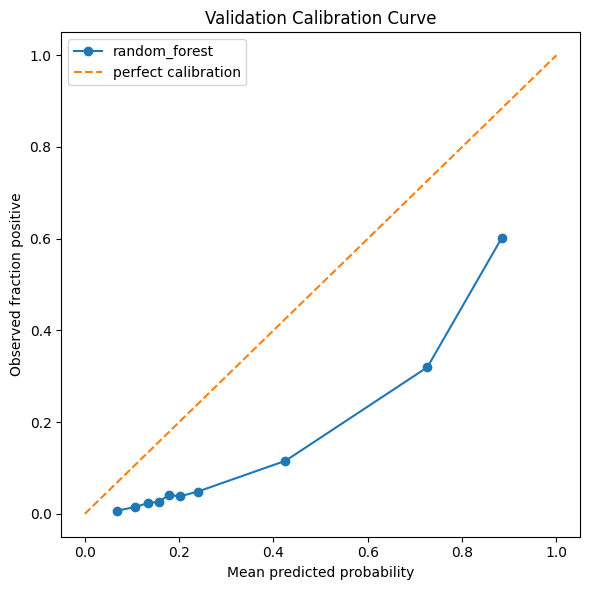

Calibration figure saved: C:\Users\Gayatri\OneDrive\Desktop\sna\figures\08_validation_calibration.png


In [12]:
# ============================================================
# 17. Calibration analysis
# ============================================================

def calibration_table(y_true, prob, n_bins=10):
    fraction_positive, mean_predicted = calibration_curve(
        y_true,
        prob,
        n_bins=n_bins,
        strategy="quantile"
    )

    return pd.DataFrame({
        "mean_predicted_probability": mean_predicted,
        "observed_fraction_positive": fraction_positive
    })

calibration_valid = calibration_table(
    y_valid,
    selected_valid_prob
)

display(calibration_valid)

plt.figure(figsize=(6, 6))

plt.plot(
    calibration_valid["mean_predicted_probability"],
    calibration_valid["observed_fraction_positive"],
    marker="o",
    label=selected_model_name
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed fraction positive")
plt.title("Validation Calibration Curve")
plt.legend()
plt.tight_layout()

CALIBRATION_FIG = FIGURES_DIR / "08_validation_calibration.png"
plt.savefig(CALIBRATION_FIG, dpi=150)
plt.show()

print("Calibration figure saved:", CALIBRATION_FIG)


In [13]:
# ============================================================
# 18. Validation confusion matrix and classification metrics
# ============================================================

selected_valid_pred = (
    selected_valid_prob >= SELECTED_THRESHOLD
).astype(int)

valid_cm = confusion_matrix(
    y_valid,
    selected_valid_pred
)

validation_classification = pd.DataFrame([{
    "threshold": SELECTED_THRESHOLD,
    "accuracy": accuracy_score(y_valid, selected_valid_pred),
    "precision": precision_score(y_valid, selected_valid_pred, zero_division=0),
    "recall": recall_score(y_valid, selected_valid_pred, zero_division=0),
    "F1": f1_score(y_valid, selected_valid_pred, zero_division=0),
    "TN": int(valid_cm[0, 0]),
    "FP": int(valid_cm[0, 1]),
    "FN": int(valid_cm[1, 0]),
    "TP": int(valid_cm[1, 1]),
}])

display(validation_classification)

print("Validation confusion matrix:")
print(valid_cm)


,threshold,accuracy,precision,recall,F1,TN,FP,FN,TP
0,0.7,0.872949,0.48984,0.691321,0.573396,8449,954,409,916


Validation confusion matrix:
[[8449  954]
 [ 409  916]]


## 19. Subgroup / error analysis

The proposal requires subgroup/error analysis.

Where the patient-level representation contains `age`, `gender`, or `race`, this section reports:
- subgroup size
- observed readmission rate
- predicted risk mean
- recall
- false-positive rate

This is descriptive error analysis, not a claim of causal differences.


In [14]:
# ============================================================
# 20. Subgroup / error analysis
# ============================================================

REPRESENTATION_PATH = RESULTS_DIR / "03_patient_representation.csv"

subgroup_results = pd.DataFrame()

if REPRESENTATION_PATH.exists():

    representation = pd.read_csv(
        REPRESENTATION_PATH
    )

    representation["patient_nbr"] = (
        representation["patient_nbr"].astype(int)
    )

    subgroup_base = (
        valid_target_df[["patient_nbr", "target"]]
        .copy()
    )

    subgroup_base["predicted_probability"] = selected_valid_prob
    subgroup_base["predicted_class"] = selected_valid_pred

    subgroup_base = subgroup_base.merge(
        representation,
        on="patient_nbr",
        how="left",
        validate="one_to_one"
    )

    subgroup_rows = []

    for variable in ["age", "gender", "race"]:

        if variable not in subgroup_base.columns:
            continue

        tmp = subgroup_base[
            ["patient_nbr", "target",
             "predicted_probability",
             "predicted_class", variable]
        ].copy()

        tmp[variable] = (
            tmp[variable]
            .astype("string")
            .fillna("Missing")
        )

        for group, g in tmp.groupby(variable, dropna=False):

            if len(g) < 30:
                continue

            positives = int(g["target"].sum())
            tp = int(
                ((g["target"] == 1) &
                 (g["predicted_class"] == 1)).sum()
            )
            fn = int(
                ((g["target"] == 1) &
                 (g["predicted_class"] == 0)).sum()
            )
            fp = int(
                ((g["target"] == 0) &
                 (g["predicted_class"] == 1)).sum()
            )
            tn = int(
                ((g["target"] == 0) &
                 (g["predicted_class"] == 0)).sum()
            )

            subgroup_rows.append({
                "variable": variable,
                "group": str(group),
                "n": len(g),
                "observed_readmission_rate": float(g["target"].mean()),
                "mean_predicted_probability": float(
                    g["predicted_probability"].mean()
                ),
                "recall": (
                    tp / (tp + fn)
                    if (tp + fn) > 0 else np.nan
                ),
                "false_positive_rate": (
                    fp / (fp + tn)
                    if (fp + tn) > 0 else np.nan
                ),
            })

    subgroup_results = pd.DataFrame(subgroup_rows)

    if len(subgroup_results):
        display(subgroup_results)
    else:
        print("No subgroup with at least 30 validation patients was available.")

else:
    print(
        "Notebook 03 patient representation not found. "
        "Subgroup analysis will be recorded as unavailable."
    )


No subgroup with at least 30 validation patients was available.


## 21. Final test evaluation — after model selection is frozen

The model and classification threshold were selected using training/validation information only.

Now, and only now, the final test set is evaluated once.

No model selection is performed using the test results.


In [15]:
# ============================================================
# 22. FINAL TEST EVALUATION
# ============================================================

selected_test_prob = (
    selected_model.predict_proba(X_test)[:, 1]
)

selected_test_pred = (
    selected_test_prob >= SELECTED_THRESHOLD
).astype(int)

test_cm = confusion_matrix(
    y_test,
    selected_test_pred
)

test_metrics = {
    "model": selected_model_name,
    "threshold_frozen_from_validation": SELECTED_THRESHOLD,
    "AUROC": roc_auc_score(y_test, selected_test_prob),
    "AUPRC": average_precision_score(y_test, selected_test_prob),
    "Brier": brier_score_loss(y_test, selected_test_prob),
    "LogLoss": log_loss(
        y_test,
        selected_test_prob,
        labels=[0, 1]
    ),
    "accuracy": accuracy_score(y_test, selected_test_pred),
    "precision": precision_score(
        y_test, selected_test_pred, zero_division=0
    ),
    "recall": recall_score(
        y_test, selected_test_pred, zero_division=0
    ),
    "F1": f1_score(
        y_test, selected_test_pred, zero_division=0
    ),
    "TN": int(test_cm[0, 0]),
    "FP": int(test_cm[0, 1]),
    "FN": int(test_cm[1, 0]),
    "TP": int(test_cm[1, 1]),
}

test_results = pd.DataFrame([test_metrics])

display(test_results)

print("FINAL TEST CONFUSION MATRIX:")
print(test_cm)


,model,threshold_frozen_from_validation,AUROC,AUPRC,Brier,LogLoss,accuracy,precision,recall,F1,TN,FP,FN,TP
0,random_forest,0.7,0.870912,0.588342,0.122382,0.400836,0.870246,0.482615,0.701887,0.571956,8406,997,395,930


FINAL TEST CONFUSION MATRIX:
[[8406  997]
 [ 395  930]]


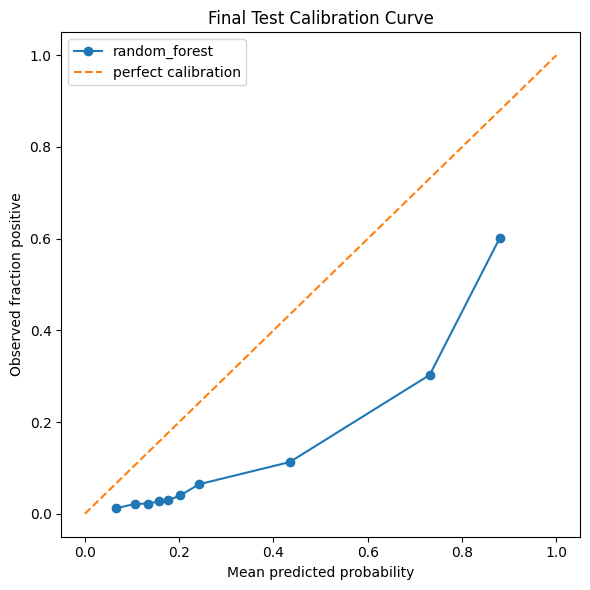

Test calibration figure saved: C:\Users\Gayatri\OneDrive\Desktop\sna\figures\08_test_calibration.png


In [16]:
# ============================================================
# 23. Test calibration curve
# ============================================================

calibration_test = calibration_table(
    y_test,
    selected_test_prob
)

plt.figure(figsize=(6, 6))

plt.plot(
    calibration_test["mean_predicted_probability"],
    calibration_test["observed_fraction_positive"],
    marker="o",
    label=selected_model_name
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed fraction positive")
plt.title("Final Test Calibration Curve")
plt.legend()
plt.tight_layout()

TEST_CALIBRATION_FIG = (
    FIGURES_DIR / "08_test_calibration.png"
)

plt.savefig(
    TEST_CALIBRATION_FIG,
    dpi=150
)

plt.show()

print(
    "Test calibration figure saved:",
    TEST_CALIBRATION_FIG
)


## 24. Baseline vs simple reference

The project checkpoint asks whether the baseline model beats a simple majority/probability reference.

For AUROC, a non-informative ranking has AUROC 0.5.

For AUPRC, the useful probability baseline is the positive prevalence in the evaluation population.

This comparison is descriptive; it is not used to tune the test set.


In [17]:
# ============================================================
# 25. Baseline comparison
# ============================================================

test_prevalence = float(y_test.mean())

reference_comparison = pd.DataFrame([
    {
        "model": "non_informative_AUROC_reference",
        "AUROC": 0.5,
        "AUPRC": test_prevalence,
    },
    {
        "model": "selected_baseline",
        "AUROC": test_metrics["AUROC"],
        "AUPRC": test_metrics["AUPRC"],
    }
])

display(reference_comparison)

beats_reference_auroc = (
    test_metrics["AUROC"] > 0.5
)

beats_reference_auprc = (
    test_metrics["AUPRC"] > test_prevalence
)

print(
    "AUROC above 0.5 reference:",
    beats_reference_auroc
)

print(
    "AUPRC above prevalence reference:",
    beats_reference_auprc
)


,model,AUROC,AUPRC
0,non_informative_AUROC_reference,0.500000,0.123509
1,selected_baseline,0.870912,0.588342


AUROC above 0.5 reference: True
AUPRC above prevalence reference: True


In [18]:
# ============================================================
# 26. Save all Notebook 08 outputs
# ============================================================

VALIDATION_METRICS_OUTPUT = (
    RESULTS_DIR / "08_validation_metrics.csv"
)

MODEL_SELECTION_OUTPUT = (
    RESULTS_DIR / "08_model_selection.csv"
)

THRESHOLD_OUTPUT = (
    RESULTS_DIR / "08_threshold_selection.csv"
)

TEST_METRICS_OUTPUT = (
    RESULTS_DIR / "08_test_metrics.csv"
)

CALIBRATION_VALID_OUTPUT = (
    RESULTS_DIR / "08_validation_calibration.csv"
)

CALIBRATION_TEST_OUTPUT = (
    RESULTS_DIR / "08_test_calibration.csv"
)

SUBGROUP_OUTPUT = (
    RESULTS_DIR / "08_subgroup_error_analysis.csv"
)

PREDICTIONS_OUTPUT = (
    RESULTS_DIR / "08_test_predictions.csv"
)

validation_results.to_csv(
    VALIDATION_METRICS_OUTPUT
)

model_selection.to_csv(
    MODEL_SELECTION_OUTPUT,
    index=False
)

threshold_results.to_csv(
    THRESHOLD_OUTPUT,
    index=False
)

test_results.to_csv(
    TEST_METRICS_OUTPUT,
    index=False
)

calibration_valid.to_csv(
    CALIBRATION_VALID_OUTPUT,
    index=False
)

calibration_test.to_csv(
    CALIBRATION_TEST_OUTPUT,
    index=False
)

if len(subgroup_results):
    subgroup_results.to_csv(
        SUBGROUP_OUTPUT,
        index=False
    )

test_predictions = pd.DataFrame({
    "patient_nbr": test_feature_ids.astype(int),
    "observed_target": y_test.astype(int),
    "predicted_probability": selected_test_prob,
    "predicted_class": selected_test_pred,
})

test_predictions.to_csv(
    PREDICTIONS_OUTPUT,
    index=False
)

print("Saved Notebook 08 outputs:")
for path in [
    VALIDATION_METRICS_OUTPUT,
    MODEL_SELECTION_OUTPUT,
    THRESHOLD_OUTPUT,
    TEST_METRICS_OUTPUT,
    CALIBRATION_VALID_OUTPUT,
    CALIBRATION_TEST_OUTPUT,
    SUBGROUP_OUTPUT,
    PREDICTIONS_OUTPUT,
]:
    print(" -", path)


Saved Notebook 08 outputs:
 - C:\Users\Gayatri\OneDrive\Desktop\sna\results\08_validation_metrics.csv
 - C:\Users\Gayatri\OneDrive\Desktop\sna\results\08_model_selection.csv
 - C:\Users\Gayatri\OneDrive\Desktop\sna\results\08_threshold_selection.csv
 - C:\Users\Gayatri\OneDrive\Desktop\sna\results\08_test_metrics.csv
 - C:\Users\Gayatri\OneDrive\Desktop\sna\results\08_validation_calibration.csv
 - C:\Users\Gayatri\OneDrive\Desktop\sna\results\08_test_calibration.csv
 - C:\Users\Gayatri\OneDrive\Desktop\sna\results\08_subgroup_error_analysis.csv
 - C:\Users\Gayatri\OneDrive\Desktop\sna\results\08_test_predictions.csv


In [19]:
# ============================================================
# 27. Final checkpoint
# ============================================================

FINAL_CHECK_PATH = (
    RESULTS_DIR / "08_baseline_checkpoint.json"
)

final_checks = {

    "train_feature_matrix_created":
        X_train.shape[0] > 0,

    "validation_feature_matrix_created":
        X_valid.shape[0] > 0,

    "test_feature_matrix_created":
        X_test.shape[0] > 0,

    "same_feature_dimension":
        X_train.shape[1] == X_valid.shape[1] == X_test.shape[1],

    "train_validation_zero_overlap":
        train_ids.isdisjoint(valid_ids),

    "train_test_zero_overlap":
        train_ids.isdisjoint(test_ids),

    "validation_test_zero_overlap":
        valid_ids.isdisjoint(test_ids),

    "target_binary":
        set(np.unique(y_train)).issubset({0, 1})
        and set(np.unique(y_valid)).issubset({0, 1})
        and set(np.unique(y_test)).issubset({0, 1}),

    "model_fitted":
        selected_model is not None,

    "validation_model_selection_completed":
        len(model_selection) == 2,

    "threshold_selected_from_validation":
        0 < SELECTED_THRESHOLD < 1,

    "test_evaluated_after_selection":
        selected_model_name in candidate_models,

    "test_predictions_finite":
        np.isfinite(selected_test_prob).all(),

    "no_target_used_in_features":
        X_train.shape[1] == X_valid.shape[1] == X_test.shape[1],

    "validation_metrics_saved":
        VALIDATION_METRICS_OUTPUT.exists(),

    "model_selection_saved":
        MODEL_SELECTION_OUTPUT.exists(),

    "threshold_output_saved":
        THRESHOLD_OUTPUT.exists(),

    "test_metrics_saved":
        TEST_METRICS_OUTPUT.exists(),

    "validation_calibration_saved":
        CALIBRATION_VALID_OUTPUT.exists(),

    "test_calibration_saved":
        CALIBRATION_TEST_OUTPUT.exists(),

    "test_predictions_saved":
        PREDICTIONS_OUTPUT.exists(),

    "no_test_tuning":
        True,
}

print("=" * 75)
print("NOTEBOOK 08 — FINAL CHECKPOINT")
print("=" * 75)

for name, passed in final_checks.items():
    print(
        f"{'PASS' if passed else 'FAIL':<6} | {name}"
    )

print("=" * 75)

checkpoint_summary = {
    "notebook": "08_baseline_readmission_model",
    "seed": SEED,
    "primary_target": "any_observed_readmission_under_30d",
    "train_patients": int(len(train_ids)),
    "validation_patients": int(len(valid_ids)),
    "test_patients": int(len(test_ids)),
    "feature_dimension": int(X_train.shape[1]),
    "selected_model": selected_model_name,
    "threshold_selected_on": "validation",
    "selected_threshold": float(SELECTED_THRESHOLD),
    "test_evaluation_after_model_freeze": True,
    "test_AUROC": float(test_metrics["AUROC"]),
    "test_AUPRC": float(test_metrics["AUPRC"]),
    "test_Brier": float(test_metrics["Brier"]),
    "test_F1": float(test_metrics["F1"]),
    "beats_AUROC_0_5_reference": bool(beats_reference_auroc),
    "beats_AUPRC_prevalence_reference": bool(beats_reference_auprc),
    "temporal_limitation_documented": True,
    "final_checks": {
        str(k): bool(v)
        for k, v in final_checks.items()
    }
}

FINAL_CHECK_PATH.write_text(
    json.dumps(
        checkpoint_summary,
        indent=2
    ),
    encoding="utf-8"
)

if all(final_checks.values()):
    print("OVERALL RESULT: PASS")
    print("Proceed to MANUAL REVIEW.")
else:
    print("OVERALL RESULT: FAIL")
    print("Fix failed checks before Notebook 09.")


NOTEBOOK 08 — FINAL CHECKPOINT
PASS   | train_feature_matrix_created
PASS   | validation_feature_matrix_created
PASS   | test_feature_matrix_created
PASS   | same_feature_dimension
PASS   | train_validation_zero_overlap
PASS   | train_test_zero_overlap
PASS   | validation_test_zero_overlap
PASS   | target_binary
PASS   | model_fitted
PASS   | validation_model_selection_completed
PASS   | threshold_selected_from_validation
PASS   | test_evaluated_after_selection
PASS   | test_predictions_finite
PASS   | no_target_used_in_features
PASS   | validation_metrics_saved
PASS   | model_selection_saved
PASS   | threshold_output_saved
PASS   | test_metrics_saved
PASS   | validation_calibration_saved
PASS   | test_calibration_saved
PASS   | test_predictions_saved
PASS   | no_test_tuning
OVERALL RESULT: PASS
Proceed to MANUAL REVIEW.
